# Health Analytics — Health Budget ML Prototype

## Project Objective

This notebook performs descriptive health and disease-indicator analytics using only the existing HMIS cleaned dataset. It produces state and indicator summaries plus a transparent, within-indicator prototype priority score. It does not infer dates, create historical observations, or perform time-series forecasting.

## 2. Import Libraries

Use pandas and numpy for summaries, and matplotlib/seaborn for charts. Resolve the project root and build paths relative to this notebook.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update(
    {
        "figure.figsize": (11, 6),
        "axes.titlesize": 14,
        "axes.labelsize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "figure.dpi": 120,
    }
)

working_directory = Path.cwd().resolve()
project_root = next(
    (
        candidate
        for candidate in (working_directory, *working_directory.parents)
        if (candidate / "data" / "cleaned").is_dir()
        and (candidate / "notebooks").is_dir()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError(
        f"Could not locate the project root from {working_directory}"
    )

notebook_directory = project_root / "notebooks"
hmis_path = (
    notebook_directory / ".." / "data" / "cleaned" / "hmis_long_normalized.csv"
).resolve()
processed_directory = (notebook_directory / ".." / "data" / "processed").resolve()
graphs_directory = (notebook_directory / ".." / "outputs" / "graphs").resolve()
reports_directory = (notebook_directory / ".." / "outputs" / "reports").resolve()

print(f"Project root: {project_root}")
print(f"HMIS input path: {hmis_path}")

Project root: C:\Users\bagad\health-budget-ml
HMIS input path: C:\Users\bagad\health-budget-ml\data\cleaned\hmis_long_normalized.csv


## 3. Load Dataset

Load only the existing cleaned HMIS snapshot. No other data sources are opened, and no date or year is inferred from the snapshot label.

In [2]:
if not hmis_path.is_file():
    raise FileNotFoundError(f"HMIS cleaned dataset not found: {hmis_path}")
hmis = pd.read_csv(hmis_path)
if hmis.empty or hmis.shape[1] == 0:
    raise ValueError("HMIS cleaned dataset has no rows or columns.")

print(f"Shape: {hmis.shape}")
print(f"Columns: {list(hmis.columns)}")
print("Data types:")
display(hmis.dtypes.rename("dtype").to_frame())
print("First 5 rows:")
display(hmis.head(5))

Shape: (101840, 9)
Columns: ['Indicator', 'S.No.', 'Parameters', 'Type', 'State', 'Observation_Category', 'Value', 'Value_Numeric', 'Reporting_Period']
Data types:


,dtype
Indicator,str
S.No.,str
Parameters,str
Type,str
State,str
Observation_Category,str
Value,float64
Value_Numeric,float64
Reporting_Period,str


First 5 rows:


,Indicator,S.No.,Parameters,Type,State,Observation_Category,Value,Value_Numeric,Reporting_Period
0,M1 [Ante Natal Care (ANC)],'1.1',Total number of pregnant women registered for ANC,TOTAL,Andaman and Nicobar Islands,Total [(A+B) or (C+D)],414.0,414.0,Source snapshot (date not inferred)
1,M1 [Ante Natal Care (ANC)],'1.1.1',"Out of the total ANC registered, number regist...",TOTAL,Andaman and Nicobar Islands,Total [(A+B) or (C+D)],317.0,317.0,Source snapshot (date not inferred)
2,M1 [Ante Natal Care (ANC)],'1.2.1',Number of PW given TT1,TOTAL,Andaman and Nicobar Islands,Total [(A+B) or (C+D)],328.0,328.0,Source snapshot (date not inferred)
3,M1 [Ante Natal Care (ANC)],'1.2.2',Number of PW given TT2,TOTAL,Andaman and Nicobar Islands,Total [(A+B) or (C+D)],199.0,199.0,Source snapshot (date not inferred)
4,M1 [Ante Natal Care (ANC)],'1.2.3',Number of PW given TT Booster,TOTAL,Andaman and Nicobar Islands,Total [(A+B) or (C+D)],57.0,57.0,Source snapshot (date not inferred)


## 4. Data Quality Summary

Summarize missingness, exact duplicate rows, and distinct states/indicators/categories/types. Identify aggregate labels once for state-level comparisons; keep the original HMIS dataframe unchanged.

In [3]:
missing_summary = hmis.isna().sum().rename("missing_count").to_frame()
missing_summary["missing_percent"] = hmis.isna().mean().mul(100).round(2)

state_labels = hmis["State"].astype("string").str.strip()
aggregate_state_mask = state_labels.str.casefold().isin({"all india/total", "total"})
state_comparison_rows = hmis.loc[~aggregate_state_mask].copy()

quality_summary = pd.DataFrame(
    {
        "Metric": [
            "Rows",
            "Columns",
            "Missing cells",
            "Exact duplicate rows",
            "Unique states (including any aggregate labels)",
            "Unique states for comparison (aggregate labels excluded)",
            "Unique indicators",
            "Observation categories",
            "Types",
        ],
        "Value": [
            len(hmis),
            hmis.shape[1],
            int(hmis.isna().sum().sum()),
            int(hmis.duplicated().sum()),
            int(hmis["State"].nunique(dropna=True)),
            int(state_comparison_rows["State"].nunique(dropna=True)),
            int(hmis["Indicator"].nunique(dropna=True)),
            int(hmis["Observation_Category"].nunique(dropna=True)),
            int(hmis["Type"].nunique(dropna=True)),
        ],
    }
)
print("Missing-value counts and percentages by column:")
display(missing_summary)
print("Overall data-quality summary:")
display(quality_summary)
print(f"Aggregate state rows excluded from state comparisons: {int(aggregate_state_mask.sum())}")

Missing-value counts and percentages by column:


,missing_count,missing_percent
Indicator,0,0.00
S.No.,0,0.00
Parameters,0,0.00
Type,0,0.00
State,0,0.00
Observation_Category,0,0.00
Value,44862,44.05
Value_Numeric,44862,44.05
Reporting_Period,0,0.00


Overall data-quality summary:


,Metric,Value
0,Rows,101840
1,Columns,9
2,Missing cells,89724
3,Exact duplicate rows,1539
4,Unique states (including any aggregate labels),37
5,Unique states for comparison (aggregate labels...,37
6,Unique indicators,25
7,Observation categories,5
8,Types,6


Aggregate state rows excluded from state comparisons: 0


## 5. State-Level Analysis

For state comparisons, exclude `Total` and `All India/Total` labels from a temporary analytical view only. Show the count for each source state label and plot the 15 most-observed states; the original HMIS rows remain intact.

States included in comparison: 37
Observation count by state:


,State,Observation_Count
0,Dadra and Nagar Haveli and Daman and Diu,5360
1,Andaman and Nicobar Islands,2680
2,Andhra Pradesh,2680
3,Arunachal Pradesh,2680
4,Assam,2680
5,Bihar,2680
6,Chandigarh,2680
7,Chhattisgarh,2680
8,Delhi,2680
9,Goa,2680


Top 15 states by observation count:


,State,Observation_Count
0,Dadra and Nagar Haveli and Daman and Diu,5360
1,Andaman and Nicobar Islands,2680
2,Andhra Pradesh,2680
3,Arunachal Pradesh,2680
4,Assam,2680
5,Bihar,2680
6,Chandigarh,2680
7,Chhattisgarh,2680
8,Delhi,2680
9,Goa,2680


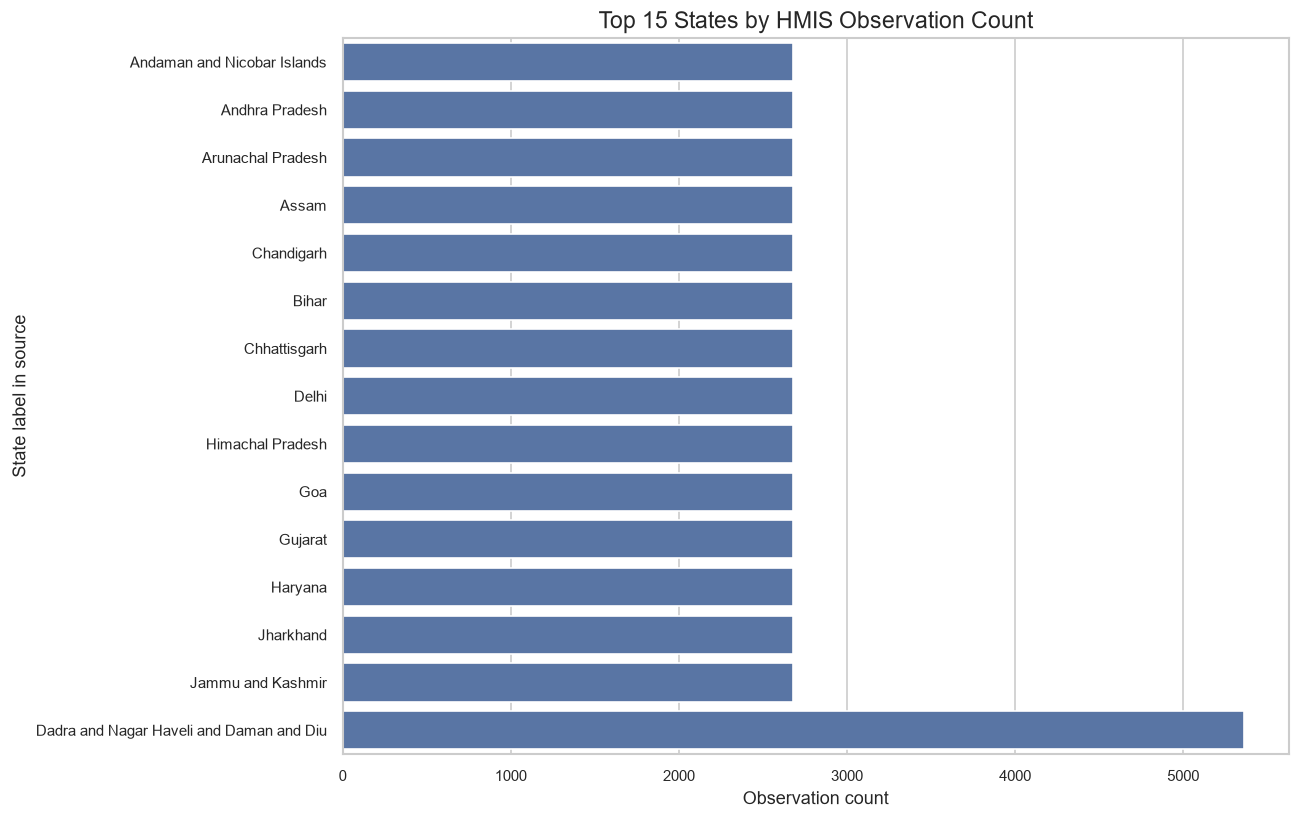

Saved chart to C:\Users\bagad\health-budget-ml\outputs\graphs\health_top_states_by_observations.png


In [4]:
state_observation_counts = (
    state_comparison_rows["State"]
    .value_counts()
    .rename_axis("State")
    .rename("Observation_Count")
)
state_observation_table = state_observation_counts.reset_index()
top_states_by_observations = state_observation_table.head(15).copy()
print(f"States included in comparison: {state_observation_counts.size}")
print("Observation count by state:")
display(state_observation_table)
print("Top 15 states by observation count:")
display(top_states_by_observations)

state_plot_data = top_states_by_observations.sort_values("Observation_Count")
graphs_directory.mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(11, max(7, 0.34 * len(state_plot_data))))
sns.barplot(
    data=state_plot_data,
    x="Observation_Count",
    y="State",
    order=state_plot_data["State"],
    color=sns.color_palette("deep")[0],
    ax=ax,
)
ax.set_title("Top 15 States by HMIS Observation Count")
ax.set_xlabel("Observation count")
ax.set_ylabel("State label in source")
fig.tight_layout()
state_observations_plot_path = graphs_directory / "health_top_states_by_observations.png"
fig.savefig(state_observations_plot_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved chart to {state_observations_plot_path}")

### Observation

`Dadra and Nagar Haveli and Daman and Diu` has 5,360 source rows, twice the 2,680 rows counted for each other displayed state label. The chart reports row counts only; it does not establish population-adjusted burden or data quality.

## 6. Health Indicator Analysis

Count records by the source `Indicator` label. Show the full indicator count table and plot a readable top-15 horizontal view.

Unique indicators: 25
Top 20 indicators by observation count:


,Indicator,Observation_Count
0,M19 [Other Items],15200
1,M17 [Vaccines],13300
2,M14 [Patient Services],10830
3,M9 [CHILD IMMUNISATION],9690
4,M18 [Family Planning],8550
5,M16 [Details of deaths reported with probable ...,7790
6,M1 [Ante Natal Care (ANC)],5130
7,M8 [Family Planning],4750
8,M15 [Laboratory Testing],3420
9,M20 [Syringes],2850


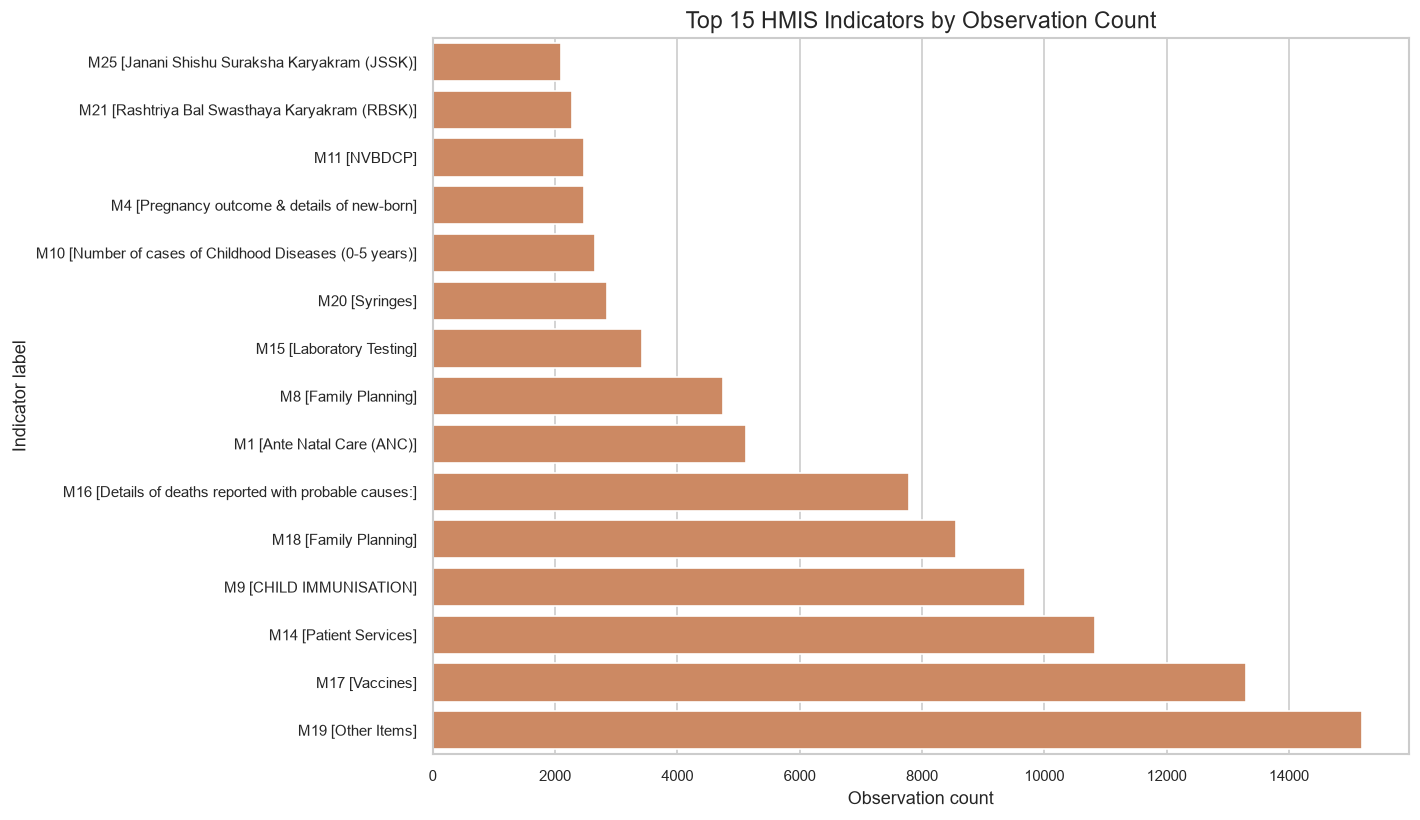

Saved chart to C:\Users\bagad\health-budget-ml\outputs\graphs\health_top_indicators.png


In [5]:
indicator_observation_counts = (
    hmis["Indicator"]
    .value_counts(dropna=False)
    .rename_axis("Indicator")
    .rename("Observation_Count")
)
indicator_observation_table = indicator_observation_counts.reset_index()
top_indicators_by_observations = indicator_observation_table.head(20).copy()
print(f"Unique indicators: {hmis['Indicator'].nunique(dropna=True)}")
print("Top 20 indicators by observation count:")
display(top_indicators_by_observations)

indicator_plot_data = indicator_observation_table.head(15).sort_values(
    "Observation_Count"
)
fig, ax = plt.subplots(figsize=(12, max(7, 0.4 * len(indicator_plot_data))))
sns.barplot(
    data=indicator_plot_data,
    x="Observation_Count",
    y="Indicator",
    order=indicator_plot_data["Indicator"],
    color=sns.color_palette("deep")[1],
    ax=ax,
)
ax.set_title("Top 15 HMIS Indicators by Observation Count")
ax.set_xlabel("Observation count")
ax.set_ylabel("Indicator label")
fig.tight_layout()
indicator_plot_path = graphs_directory / "health_top_indicators.png"
fig.savefig(indicator_plot_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved chart to {indicator_plot_path}")

### Observation

`M19 [Other Items]`, `M17 [Vaccines]`, and `M14 [Patient Services]` have the largest row counts in this source. Observation frequency reflects coverage in the snapshot, not disease severity or health burden.

## 7. Observation Category Analysis

Show the exact category labels, row counts, and percentages of all HMIS records. Categories remain separate because they represent different observation groupings.

Unique Observation_Category values: 5


,Observation_Category,Record_Count,Percentage
0,Total [(A+B) or (C+D)],20368,20.0
1,Public [A],20368,20.0
2,Private [B],20368,20.0
3,Urban [C],20368,20.0
4,Rural [D],20368,20.0


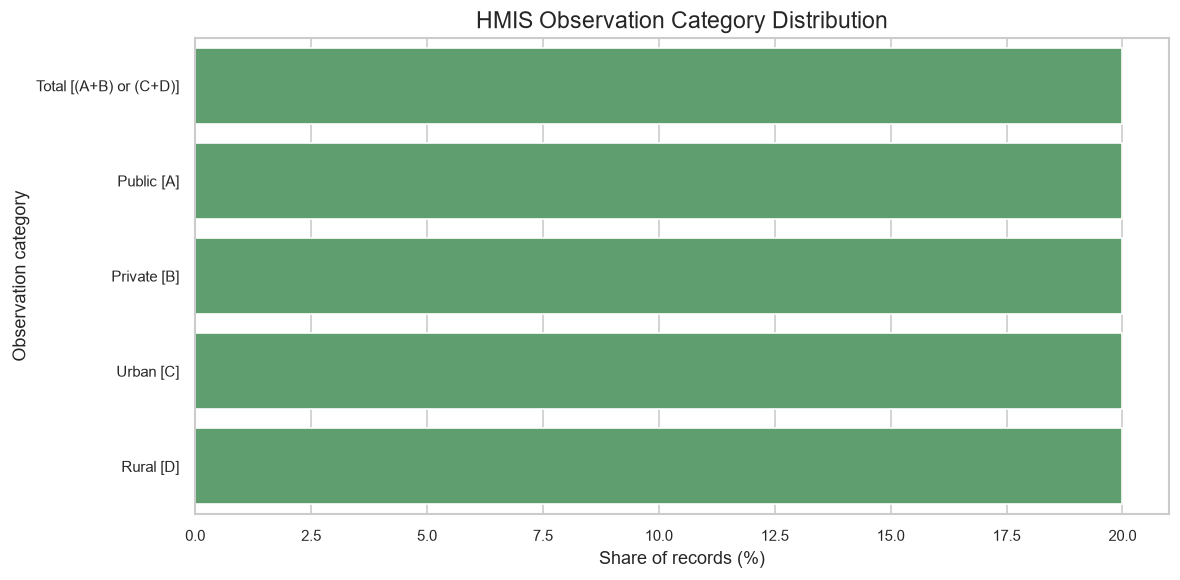

Saved chart to C:\Users\bagad\health-budget-ml\outputs\graphs\health_observation_category_distribution.png


In [6]:
category_summary = (
    hmis["Observation_Category"]
    .value_counts(dropna=False)
    .rename_axis("Observation_Category")
    .rename("Record_Count")
    .to_frame()
)
category_summary["Percentage"] = (
    category_summary["Record_Count"] / len(hmis) * 100
)
category_summary = category_summary.reset_index()
print("Unique Observation_Category values:", hmis["Observation_Category"].nunique(dropna=True))
display(category_summary.round({"Percentage": 2}))

category_plot_data = category_summary.sort_values("Percentage")
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=category_plot_data,
    x="Percentage",
    y="Observation_Category",
    order=category_plot_data["Observation_Category"],
    color=sns.color_palette("deep")[2],
    ax=ax,
)
ax.set_title("HMIS Observation Category Distribution")
ax.set_xlabel("Share of records (%)")
ax.set_ylabel("Observation category")
fig.tight_layout()
category_plot_path = graphs_directory / "health_observation_category_distribution.png"
fig.savefig(category_plot_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved chart to {category_plot_path}")

### Observation

The five observation categories each account for 20,368 records (20% of the file). Equal row counts are visible in this snapshot; they do not establish that categories have equal populations or health burden.

## 8. Numeric Health Value Analysis

Summarize `Value_Numeric` over all non-missing numeric observations. Because indicators may use different measures/units, these pooled statistics and the distribution chart are descriptive only and must not be interpreted as a common health scale. Identify indicators meeting a transparent minimum coverage rule: at least 20 numeric rows across at least 3 non-aggregate state labels.

Value_Numeric missing: 44,862 rows (44.05%).
Pooled Value_Numeric descriptive statistics (indicators may have different units):


,Statistic,Value
0,count,5.697800e+04
1,mean,9.826132e+04
2,median,1.190000e+02
3,minimum,-4.290910e+05
4,maximum,1.082083e+08
5,standard_deviation,1.635101e+06


Coverage rule: at least 20 numeric rows across at least 3 individual state labels.
Indicators meeting descriptive coverage rule: 25 of 25


,Indicator,Numeric_Observation_Count,Numeric_State_Count,Mean_Value,Median_Value,Min_Value,Max_Value,Std_Value,Enough_For_Descriptive_Summary
5,M14 [Patient Services],9325,35,5.436934e+04,330.0,0.0,19265192.0,5.424460e+05,True
24,M9 [CHILD IMMUNISATION],8834,35,1.767475e+04,447.0,0.0,3643252.0,9.598990e+04,True
7,M16 [Details of deaths reported with probable ...,6976,35,8.010636e+01,1.0,0.0,11811.0,5.009118e+02,True
0,M1 [Ante Natal Care (ANC)],4574,35,1.223128e+04,278.0,0.0,401164.0,3.440673e+04,True
23,M8 [Family Planning],4307,35,2.038756e+04,26.0,0.0,2664285.0,1.575726e+05,True
6,M15 [Laboratory Testing],3079,35,8.396920e+04,604.0,0.0,11873765.0,5.268277e+05,True
10,M19 [Other Items],2604,35,1.504545e+06,20.0,-59809.0,108208275.0,7.384979e+06,True
8,M17 [Vaccines],2440,35,5.793477e+04,3349.5,0.0,6981688.0,2.205959e+05,True
1,M10 [Number of cases of Childhood Diseases (0-...,2417,35,6.726889e+02,9.0,0.0,64922.0,3.676392e+03,True
19,M4 [Pregnancy outcome & details of new-born],2271,35,6.088289e+03,210.0,0.0,181706.0,1.752510e+04,True


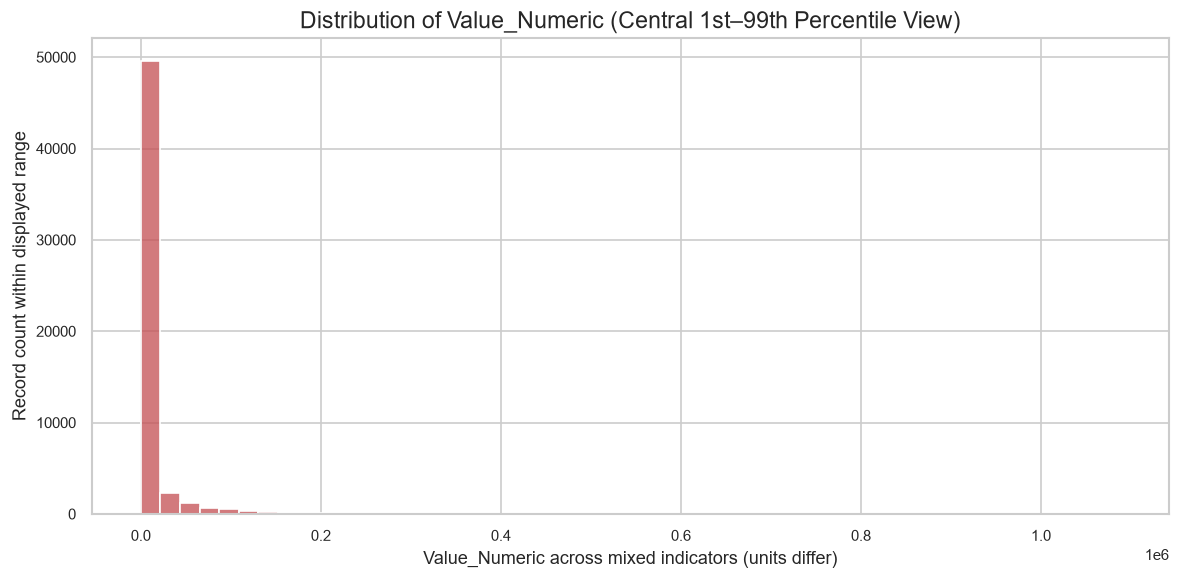

Histogram view range: 0.000 to 1,089,751.420; all non-missing rows remain included in summary statistics.
Saved chart to C:\Users\bagad\health-budget-ml\outputs\graphs\health_numeric_value_distribution.png


In [7]:
numeric_values = hmis["Value_Numeric"].dropna()
value_numeric_missing_percent = hmis["Value_Numeric"].isna().mean() * 100
value_numeric_summary = pd.DataFrame(
    {
        "Statistic": ["count", "mean", "median", "minimum", "maximum", "standard_deviation"],
        "Value": [
            int(numeric_values.count()),
            float(numeric_values.mean()),
            float(numeric_values.median()),
            float(numeric_values.min()),
            float(numeric_values.max()),
            float(numeric_values.std()),
        ],
    }
)
print(f"Value_Numeric missing: {int(hmis['Value_Numeric'].isna().sum()):,} rows ({value_numeric_missing_percent:.2f}%).")
print("Pooled Value_Numeric descriptive statistics (indicators may have different units):")
display(value_numeric_summary)

minimum_numeric_rows = 20
minimum_numeric_states = 3
numeric_indicator_rows = state_comparison_rows.loc[
    state_comparison_rows["Value_Numeric"].notna()
]
indicator_numeric_coverage = (
    numeric_indicator_rows.groupby("Indicator")
    .agg(
        Numeric_Observation_Count=("Value_Numeric", "count"),
        Numeric_State_Count=("State", "nunique"),
        Mean_Value=("Value_Numeric", "mean"),
        Median_Value=("Value_Numeric", "median"),
        Min_Value=("Value_Numeric", "min"),
        Max_Value=("Value_Numeric", "max"),
        Std_Value=("Value_Numeric", "std"),
    )
    .reset_index()
)
indicator_numeric_coverage["Enough_For_Descriptive_Summary"] = (
    indicator_numeric_coverage["Numeric_Observation_Count"].ge(minimum_numeric_rows)
    & indicator_numeric_coverage["Numeric_State_Count"].ge(minimum_numeric_states)
)
indicators_with_coverage = indicator_numeric_coverage.loc[
    indicator_numeric_coverage["Enough_For_Descriptive_Summary"]
].sort_values("Numeric_Observation_Count", ascending=False)
print(
    "Coverage rule: at least "
    f"{minimum_numeric_rows} numeric rows across at least "
    f"{minimum_numeric_states} individual state labels."
)
print(
    f"Indicators meeting descriptive coverage rule: "
    f"{len(indicators_with_coverage)} of {hmis['Indicator'].nunique()}"
)
display(indicators_with_coverage)

lower_value_quantile, upper_value_quantile = numeric_values.quantile([0.01, 0.99])
plot_values = numeric_values.loc[
    numeric_values.between(lower_value_quantile, upper_value_quantile)
]
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(plot_values, bins=50, color=sns.color_palette("deep")[3], ax=ax)
ax.set_title("Distribution of Value_Numeric (Central 1st–99th Percentile View)")
ax.set_xlabel("Value_Numeric across mixed indicators (units differ)")
ax.set_ylabel("Record count within displayed range")
fig.tight_layout()
numeric_distribution_plot_path = graphs_directory / "health_numeric_value_distribution.png"
fig.savefig(numeric_distribution_plot_path, dpi=160, bbox_inches="tight")
plt.show()
print(
    "Histogram view range: "
    f"{lower_value_quantile:,.3f} to {upper_value_quantile:,.3f}; "
    "all non-missing rows remain included in summary statistics."
)
print(f"Saved chart to {numeric_distribution_plot_path}")

## 9. State × Indicator Analysis

Aggregate numeric HMIS records to State and Indicator using only non-missing `Value_Numeric`. This follows the requested grouping and can combine multiple source parameters/categories under a broad indicator; treat the resulting statistics as descriptive and not as a harmonized measure.

In [8]:
numeric_state_rows = state_comparison_rows.loc[
    state_comparison_rows["Value_Numeric"].notna()
]
state_indicator_analysis = (
    numeric_state_rows.groupby(["State", "Indicator"], as_index=False)
    .agg(
        Observation_Count=("Value_Numeric", "count"),
        Mean_Value=("Value_Numeric", "mean"),
        Median_Value=("Value_Numeric", "median"),
        Min_Value=("Value_Numeric", "min"),
        Max_Value=("Value_Numeric", "max"),
    )
    .sort_values(["State", "Indicator"])
    .reset_index(drop=True)
)
print(f"State × Indicator numeric summary shape: {state_indicator_analysis.shape}")
print("Sample aggregated rows:")
display(state_indicator_analysis.head(10))

State × Indicator numeric summary shape: (865, 7)
Sample aggregated rows:


,State,Indicator,Observation_Count,Mean_Value,Median_Value,Min_Value,Max_Value
0,Andaman and Nicobar Islands,M1 [Ante Natal Care (ANC)],106,134.603774,36.0,0.0,790.0
1,Andaman and Nicobar Islands,M10 [Number of cases of Childhood Diseases (0-...,56,10.232143,0.0,0.0,113.0
2,Andaman and Nicobar Islands,M11 [NVBDCP],49,111.918367,0.0,0.0,1411.0
3,Andaman and Nicobar Islands,M12 [Adolscent Health],24,102.125000,97.5,0.0,252.0
4,Andaman and Nicobar Islands,"M13 [Directly Observed Treatment, Short-course...",8,28.125000,21.0,4.0,54.0
5,Andaman and Nicobar Islands,M14 [Patient Services],207,3055.231884,53.0,0.0,143666.0
6,Andaman and Nicobar Islands,M15 [Laboratory Testing],70,4043.014286,64.0,0.0,73508.0
7,Andaman and Nicobar Islands,M16 [Details of deaths reported with probable ...,163,1.858896,0.0,0.0,33.0
8,Andaman and Nicobar Islands,M17 [Vaccines],70,798.914286,330.5,0.0,5612.0
9,Andaman and Nicobar Islands,M18 [Family Planning],45,6710.488889,387.0,-128889.0,130200.0


## 10. Health Burden / Priority Prototype

Create a demonstration score only where `Value_Numeric` exists. Normalize within each `Indicator × Observation_Category` group using individual-state observations, so mixed units are not compared directly. Higher source numeric magnitude is assigned a higher score only as a transparent prototype convention; the score does not encode clinical direction and is not an official government health-burden score. Aggregate rows remain in the dataset but are excluded from score normalization.

In [9]:
priority_score_column = "Prototype_Indicator_Priority_Score"
priority_eligible_mask = ~aggregate_state_mask & hmis["Value_Numeric"].notna()
priority_source = hmis.loc[
    priority_eligible_mask,
    ["Indicator", "Observation_Category", "Value_Numeric"],
].copy()
priority_group_columns = ["Indicator", "Observation_Category"]
priority_grouped = priority_source.groupby(
    priority_group_columns, dropna=False
)["Value_Numeric"]
priority_minimum = priority_grouped.transform("min")
priority_maximum = priority_grouped.transform("max")
priority_range = priority_maximum - priority_minimum

priority_scores = pd.Series(
    np.where(
        priority_range.gt(0),
        (priority_source["Value_Numeric"] - priority_minimum)
        / priority_range.where(priority_range.gt(0), 1),
        0.0,
    ),
    index=priority_source.index,
    dtype="float64",
)
hmis_analytics = hmis.copy()
hmis_analytics[priority_score_column] = np.nan
hmis_analytics.loc[priority_eligible_mask, priority_score_column] = priority_scores

assert hmis_analytics.loc[
    ~priority_eligible_mask, priority_score_column
].isna().all()
assert hmis_analytics.loc[
    priority_eligible_mask, priority_score_column
].between(0, 1).all()
print(f"Rows with numeric values and eligible individual-state labels: {int(priority_eligible_mask.sum()):,}")
print(f"Rows without a prototype score (missing numeric value or aggregate label): {int(hmis_analytics[priority_score_column].isna().sum()):,}")
print(
    "Normalization groups:",
    hmis_analytics.loc[priority_eligible_mask, priority_group_columns]
    .drop_duplicates()
    .shape[0],
)
print("Score range among eligible rows:")
display(hmis_analytics[priority_score_column].describe().to_frame().T)
print("Prototype score sample:")
display(
    hmis_analytics.loc[
        priority_eligible_mask,
        ["State", "Indicator", "Observation_Category", "Value_Numeric", priority_score_column],
    ].head(10)
)

Rows with numeric values and eligible individual-state labels: 56,978
Rows without a prototype score (missing numeric value or aggregate label): 44,862
Normalization groups: 89
Score range among eligible rows:


,count,mean,std,min,25%,50%,75%,max
Prototype_Indicator_Priority_Score,56978.0,0.024498,0.090063,0.0,0.000001,0.000348,0.006277,1.0


Prototype score sample:


,State,Indicator,Observation_Category,Value_Numeric,Prototype_Indicator_Priority_Score
0,Andaman and Nicobar Islands,M1 [Ante Natal Care (ANC)],Total [(A+B) or (C+D)],414.0,0.001032
1,Andaman and Nicobar Islands,M1 [Ante Natal Care (ANC)],Total [(A+B) or (C+D)],317.0,0.000790
2,Andaman and Nicobar Islands,M1 [Ante Natal Care (ANC)],Total [(A+B) or (C+D)],328.0,0.000818
3,Andaman and Nicobar Islands,M1 [Ante Natal Care (ANC)],Total [(A+B) or (C+D)],199.0,0.000496
4,Andaman and Nicobar Islands,M1 [Ante Natal Care (ANC)],Total [(A+B) or (C+D)],57.0,0.000142
5,Andaman and Nicobar Islands,M1 [Ante Natal Care (ANC)],Total [(A+B) or (C+D)],260.0,0.000648
6,Andaman and Nicobar Islands,M1 [Ante Natal Care (ANC)],Total [(A+B) or (C+D)],180.0,0.000449
7,Andaman and Nicobar Islands,M1 [Ante Natal Care (ANC)],Total [(A+B) or (C+D)],206.0,0.000514
8,Andaman and Nicobar Islands,M1 [Ante Natal Care (ANC)],Total [(A+B) or (C+D)],503.0,0.001254
9,Andaman and Nicobar Islands,M1 [Ante Natal Care (ANC)],Total [(A+B) or (C+D)],4.0,0.000010


## 11. State-Level Priority Analysis

Summarize the prototype score by non-aggregate State. Show the number of contributing indicators and average score. This ordering is a demonstration ranking from observed numeric magnitude only, not an official health or government priority ranking.

State-level prototype priority summary (not an official ranking):


,State,Number_of_Indicators,Average_Prototype_Indicator_Priority_Score
0,Maharashtra,25,0.0859
1,Uttar Pradesh,25,0.0806
2,Tamil Nadu,25,0.0668
3,West Bengal,25,0.0584
4,Madhya Pradesh,25,0.0546
5,Karnataka,25,0.0546
6,Gujarat,25,0.0490
7,Rajasthan,25,0.0434
8,Bihar,25,0.0400
9,Andhra Pradesh,25,0.0398


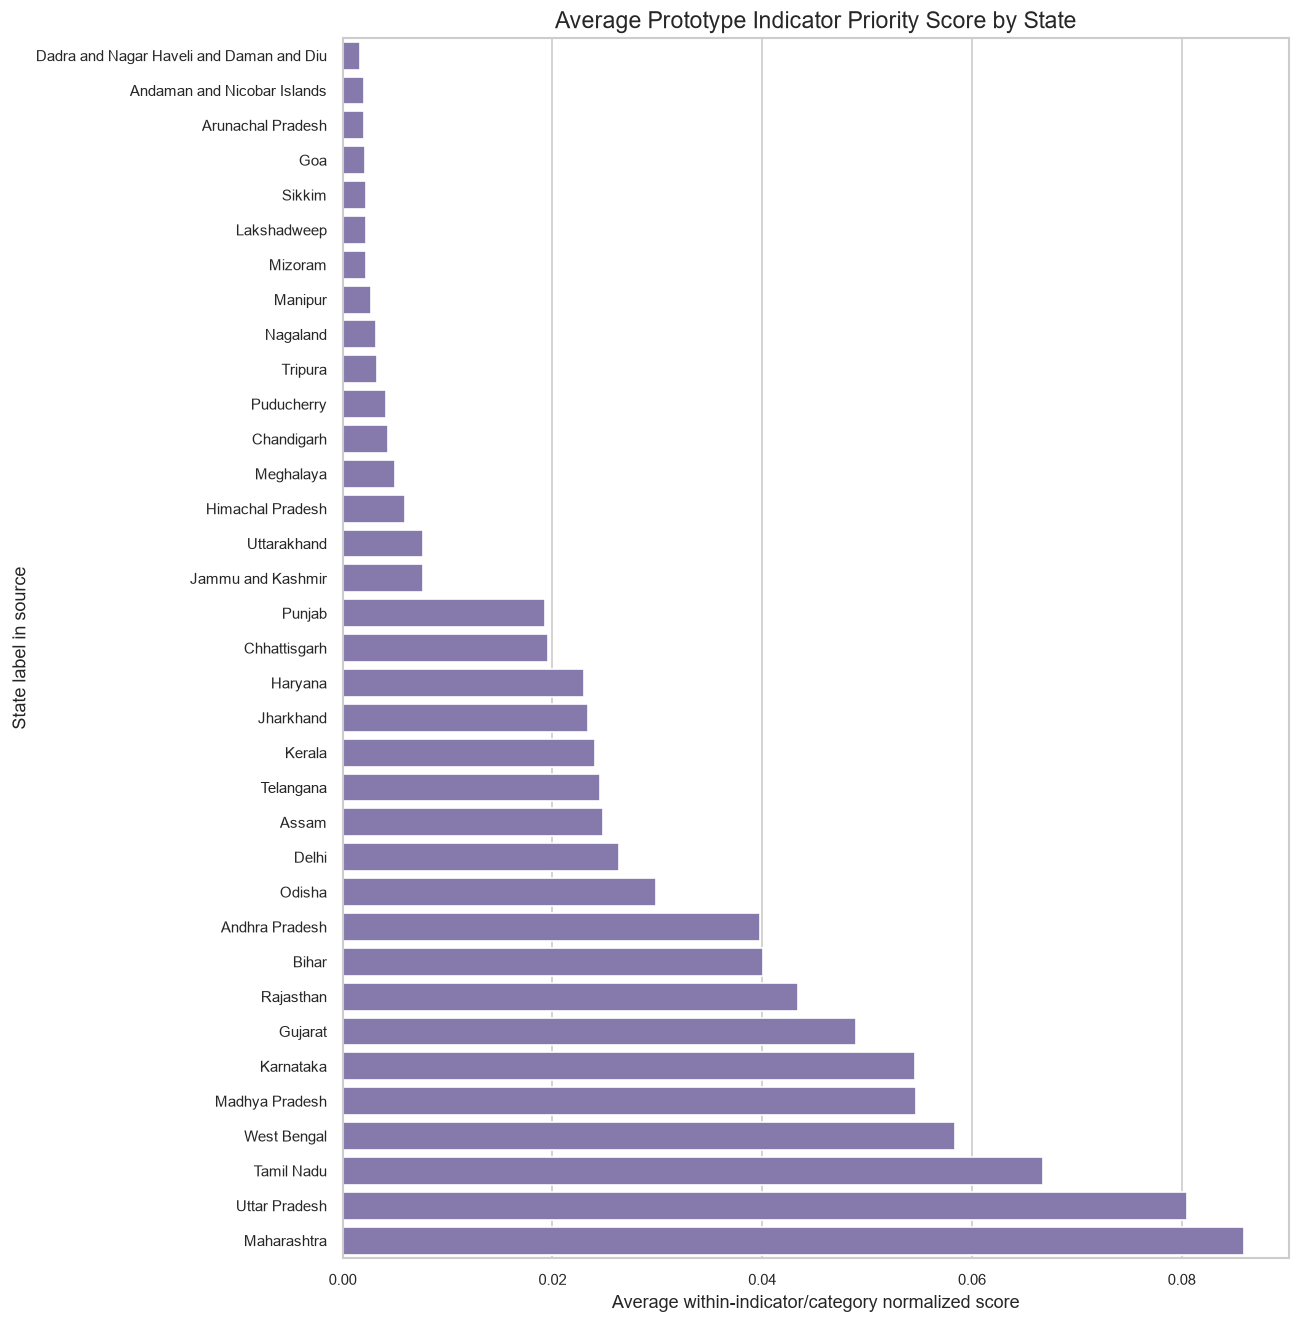

Saved chart to C:\Users\bagad\health-budget-ml\outputs\graphs\health_state_prototype_priority.png


In [10]:
scored_individual_rows = hmis_analytics.loc[
    hmis_analytics[priority_score_column].notna()
].copy()
state_priority_summary = (
    scored_individual_rows.groupby("State", as_index=False)
    .agg(
        Number_of_Indicators=("Indicator", "nunique"),
        Average_Prototype_Indicator_Priority_Score=(priority_score_column, "mean"),
    )
    .sort_values("Average_Prototype_Indicator_Priority_Score", ascending=False)
    .reset_index(drop=True)
)
print("State-level prototype priority summary (not an official ranking):")
display(state_priority_summary.round(4))

state_priority_plot_data = state_priority_summary.sort_values(
    "Average_Prototype_Indicator_Priority_Score", ascending=True
)
fig, ax = plt.subplots(
    figsize=(11, max(8, 0.32 * len(state_priority_plot_data)))
)
sns.barplot(
    data=state_priority_plot_data,
    x="Average_Prototype_Indicator_Priority_Score",
    y="State",
    order=state_priority_plot_data["State"],
    color=sns.color_palette("deep")[4],
    ax=ax,
)
ax.set_title("Average Prototype Indicator Priority Score by State")
ax.set_xlabel("Average within-indicator/category normalized score")
ax.set_ylabel("State label in source")
fig.tight_layout()
state_priority_plot_path = graphs_directory / "health_state_prototype_priority.png"
fig.savefig(state_priority_plot_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved chart to {state_priority_plot_path}")

## 12. Saved Visualizations

The notebook creates five charts: top states by observations, top indicators, observation categories, the central-range `Value_Numeric` distribution, and state-level prototype priority. The numeric distribution chart displays the central 1st–99th percentile range for readability; all numeric observations remain in the summary and analytical data.

In [11]:
visualization_paths = {
    "Top states by observations": state_observations_plot_path,
    "Top indicators": indicator_plot_path,
    "Observation category distribution": category_plot_path,
    "Value_Numeric distribution": numeric_distribution_plot_path,
    "State prototype priority": state_priority_plot_path,
}
visualization_inventory = pd.DataFrame(
    [
        {
            "Visualization": name,
            "Path": str(path),
            "Saved": path.is_file(),
        }
        for name, path in visualization_paths.items()
    ]
)
display(visualization_inventory)
if not visualization_inventory["Saved"].all():
    raise FileNotFoundError("One or more required health analytics charts were not saved.")

,Visualization,Path,Saved
0,Top states by observations,C:\Users\bagad\health-budget-ml\outputs\graphs...,True
1,Top indicators,C:\Users\bagad\health-budget-ml\outputs\graphs...,True
2,Observation category distribution,C:\Users\bagad\health-budget-ml\outputs\graphs...,True
3,Value_Numeric distribution,C:\Users\bagad\health-budget-ml\outputs\graphs...,True
4,State prototype priority,C:\Users\bagad\health-budget-ml\outputs\graphs...,True


## 13. Save Processed HMIS Analytics

Save a full analytical view with the original HMIS fields and the prototype score column. Missing-value rows remain present; the score stays missing where numeric input is unavailable or the row is aggregate-only.

In [12]:
processed_directory.mkdir(parents=True, exist_ok=True)
processed_hmis_path = processed_directory / "hmis_health_analytics.csv"
hmis_analytics.to_csv(processed_hmis_path, index=False)
print(f"Saved processed analytics: {processed_hmis_path}")
print(f"Rows saved: {len(hmis_analytics):,}; source rows: {len(hmis):,}")
print(f"Columns saved: {list(hmis_analytics.columns)}")
assert len(hmis_analytics) == len(hmis)
assert hmis_analytics["Prototype_Indicator_Priority_Score"].isna().sum() >= int(
    hmis["Value_Numeric"].isna().sum()
)

Saved processed analytics: C:\Users\bagad\health-budget-ml\data\processed\hmis_health_analytics.csv
Rows saved: 101,840; source rows: 101,840
Columns saved: ['Indicator', 'S.No.', 'Parameters', 'Type', 'State', 'Observation_Category', 'Value', 'Value_Numeric', 'Reporting_Period', 'Prototype_Indicator_Priority_Score']


## 14. Generate Summary Report

Write a compact CSV summary of source quality, coverage, indicator volume, numeric availability, reporting-period usability, and prototype-score coverage. Findings describe this source snapshot only.

In [14]:
reporting_period_values = hmis["Reporting_Period"].dropna().unique().tolist()
print(f"Reporting_Period unique values for the report: {reporting_period_values}")

Reporting_Period unique values for the report: ['Source snapshot (date not inferred)']


In [15]:
reporting_period_date_rows = int(
    pd.to_datetime(hmis["Reporting_Period"], errors="coerce", format="mixed")
    .notna()
    .sum()
)
reporting_period_year_rows = int(
    hmis["Reporting_Period"]
    .astype("string")
    .str.contains(r"\b(?:19|20)\d{2}\b", regex=True, na=False)
    .sum()
)
top_state_label = state_observation_counts.index[0]
top_indicator_label = indicator_observation_counts.index[0]
top_priority_state = state_priority_summary.iloc[0]

summary_report = pd.DataFrame(
    [
        {"Metric": "HMIS rows", "Value": len(hmis), "Interpretation": "Rows in the source snapshot."},
        {"Metric": "HMIS columns", "Value": hmis.shape[1], "Interpretation": "Columns in the source snapshot."},
        {"Metric": "Exact duplicate rows", "Value": int(hmis.duplicated().sum()), "Interpretation": "Reported only; no rows were removed."},
        {"Metric": "Unique state labels", "Value": hmis["State"].nunique(dropna=True), "Interpretation": "Exact source labels; no external canonical list applied."},
        {"Metric": "Unique indicators", "Value": hmis["Indicator"].nunique(dropna=True), "Interpretation": "Distinct Indicator values."},
        {"Metric": "Observation categories", "Value": hmis["Observation_Category"].nunique(dropna=True), "Interpretation": "Distinct source category values."},
        {"Metric": "Types", "Value": hmis["Type"].nunique(dropna=True), "Interpretation": "Distinct source Type values."},
        {"Metric": "Value_Numeric missing rows", "Value": int(hmis["Value_Numeric"].isna().sum()), "Interpretation": "Missing values were not converted to zero."},
        {"Metric": "Value_Numeric missing percent", "Value": round(float(value_numeric_missing_percent), 2), "Interpretation": "Percentage of all HMIS rows."},
        {"Metric": "Reporting_Period values", "Value": " | ".join(reporting_period_values), "Interpretation": "Source snapshot label; no date inferred."},
        {"Metric": "Reporting_Period parseable date rows", "Value": reporting_period_date_rows, "Interpretation": "No time-series date available when zero."},
        {"Metric": "Reporting_Period rows containing four-digit year", "Value": reporting_period_year_rows, "Interpretation": "No year inferred from other fields."},
        {"Metric": "Indicators meeting descriptive coverage rule", "Value": len(indicators_with_coverage), "Interpretation": f"At least {minimum_numeric_rows} numeric rows across {minimum_numeric_states} individual state labels."},
        {"Metric": "Rows with prototype priority score", "Value": int(hmis_analytics[priority_score_column].notna().sum()), "Interpretation": "Min-max normalized within Indicator × Observation_Category among individual states."},
        {"Metric": "Most-observed state label", "Value": str(top_state_label), "Interpretation": f"{int(state_observation_counts.iloc[0])} source rows; not population adjusted."},
        {"Metric": "Most-observed indicator", "Value": str(top_indicator_label), "Interpretation": f"{int(indicator_observation_counts.iloc[0])} source rows; frequency is not severity."},
        {"Metric": "Highest-average prototype-score state", "Value": str(top_priority_state["State"]), "Interpretation": f"Score {top_priority_state['Average_Prototype_Indicator_Priority_Score']:.4f}; demonstration only, not official ranking."},
    ]
)
reports_directory.mkdir(parents=True, exist_ok=True)
summary_report_path = reports_directory / "health_analytics_summary.csv"
summary_report.to_csv(summary_report_path, index=False)
print(f"Saved summary report to {summary_report_path}")
display(summary_report)

Saved summary report to C:\Users\bagad\health-budget-ml\outputs\reports\health_analytics_summary.csv


,Metric,Value,Interpretation
0,HMIS rows,101840,Rows in the source snapshot.
1,HMIS columns,9,Columns in the source snapshot.
2,Exact duplicate rows,1539,Reported only; no rows were removed.
3,Unique state labels,37,Exact source labels; no external canonical lis...
4,Unique indicators,25,Distinct Indicator values.
5,Observation categories,5,Distinct source category values.
6,Types,6,Distinct source Type values.
7,Value_Numeric missing rows,44862,Missing values were not converted to zero.
8,Value_Numeric missing percent,44.05,Percentage of all HMIS rows.
9,Reporting_Period values,Source snapshot (date not inferred),Source snapshot label; no date inferred.


## 15. Limitations

- HMIS is a source snapshot, not a dated historical series.
- `Reporting_Period` is `Source snapshot (date not inferred)`; no reliable year, month, or date is present, and none is inferred here.
- This notebook does not perform time-series forecasting.
- Indicators and parameters can measure different concepts and units; pooled numeric statistics and cross-indicator comparisons are limited.
- The prototype score is a within-indicator/category min-max demonstration based on numeric magnitude. It is not a clinical severity direction or an official government health-burden score.
- Missing values are not automatically treated as zero, and no rows are deleted merely because values are missing.
- Aggregate labels are excluded from state comparisons and prototype-score normalization, but original rows remain in the source and processed output.
- Exact duplicate rows are reported, not removed.

## 16. Final ML Readiness Statement

| Use case | Current HMIS suitability | Qualification |
|---|---|---|
| Descriptive analytics | Suitable for academic prototype | Interpret numeric summaries within indicator/parameter context; missing values remain visible. |
| State comparison | Suitable with limitations | Counts and prototype scores are based on source labels, not population-adjusted measures; aggregate labels are excluded. |
| Indicator analysis | Suitable with limitations | Indicator meanings and units differ; row count is coverage, not severity. |
| Prototype priority scoring | Suitable as a demonstration only | Within-indicator/category numeric min-max score; not an official or clinically directed health-burden score. |
| Time-series disease forecasting | Not suitable | No reliable reporting year/month/date exists in this snapshot. |

**Conclusion:** This HMIS file supports descriptive analytics, state/indicator summaries, and a transparent prototype score only. It does not support time-series disease forecasting. Documented historical HMIS observations with reliable reporting dates are required before forecasting features can be justified.

## 17. Final Output

The source HMIS CSV is unchanged; the processed analytical view and summary report are saved separately.

In [16]:
print("Notebook 06 completed successfully.")

Notebook 06 completed successfully.
